### Code to produce the standard plots

In [9]:
# imports
import os
import numpy as np
import matplotlib.pyplot as plt

##### cvh Plot

Plot saved successfully to Plots/heisenberg_spin_3_half_cvh.pdf


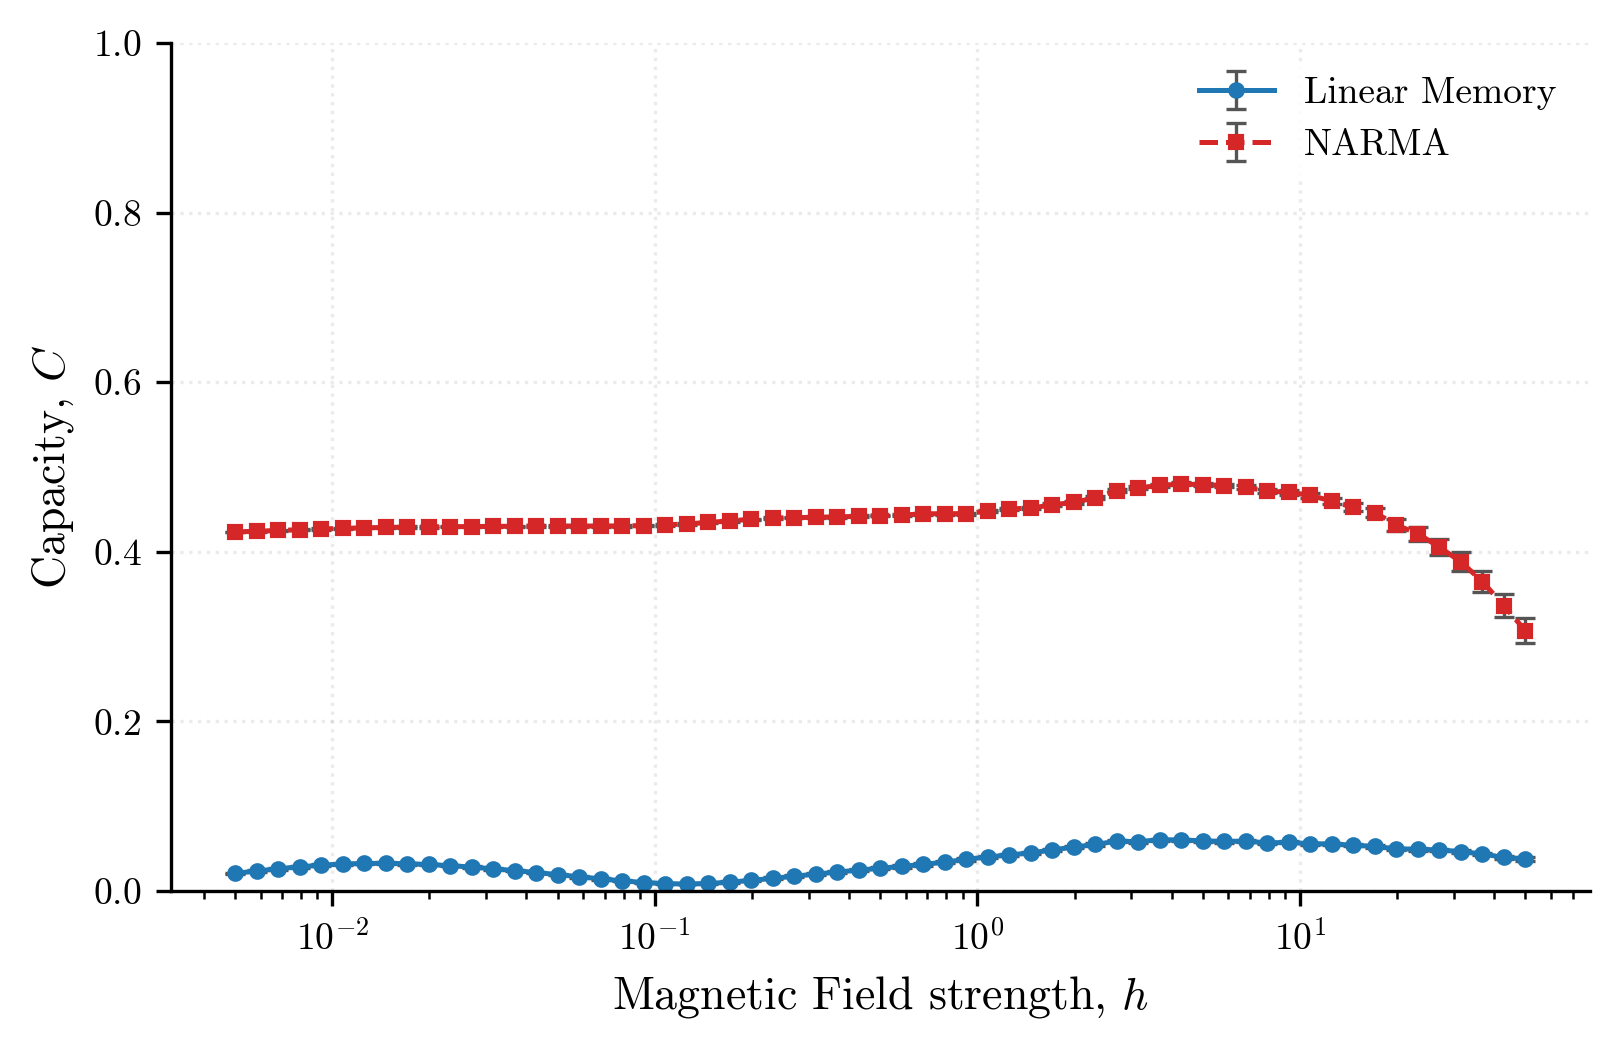

In [ ]:
def configure_academic_style():
    """Returns a clean dictionary of publication-ready matplotlib parameters."""
    return {
        "font.family": "serif",
        "font.serif": [
            "cmr10",
            "DejaVu Serif",
            "Liberation Serif",
            "Bitstream Vera Serif",
        ],
        "mathtext.fontset": "cm",  # Native Computer Modern math font
        "axes.formatter.use_mathtext": True,  # Fixes the UserWarning for cmr10 tick formatting
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": ":",
        "figure.autolayout": True,
    }

def plot_capacity_vs_h(
    data_path: str,
    output_path: str = None,
    *,
    # Scale Options
    xscale: str = "log",           # 'linear', 'log', 'symlog', etc.
    yscale: str = "linear",        # 'linear', 'log', 'symlog', etc.
    # Fill Options
    show_fill: bool = True,        # Toggle std deviation bands
    fill_std_multiplier: float = 1.0, # e.g., 1.0 for ±1σ, 0.5 for ±0.5σ, 2.0 for ±2σ
    fill_alpha: float = 0.15       # Transparency of fill bands (0.0 to 1.0)
):
    """
    Plots Capacity vs. Magnetic Field with configurable scales and standard deviation bands.
    """
    # 1. Load Data safely
    if os.path.exists(data_path):
        data = np.load(data_path)
        h_values = data["h_values"]
        c_mean_lin = data["c_mean_LinMem"]
        c_se_lin = data["c_se_LinMem"]
        c_std_lin = data["c_std_LinMem"]

        c_mean_narma = data["c_mean_NARMA"]
        c_se_narma = data["c_se_NARMA"]
        c_std_narma = data["c_std_NARMA"]
    else:
        # Mock fallback data for testing
        h_values = np.logspace(-2, 2, 25)
        c_mean_lin = 1.0 / (1.0 + 0.5 * h_values)
        c_se_lin = 0.03 * np.ones_like(h_values)
        c_std_lin = 0.12 * np.ones_like(h_values)

        c_mean_narma = 0.8 / (1.0 + 0.8 * h_values)
        c_se_narma = 0.025 * np.ones_like(h_values)
        c_std_narma = 0.10 * np.ones_like(h_values)

    # 2. Define colors
    color_linmem = "#1f77b4"  # Muted Blue
    color_narma = "#d62728"   # Crimson Red
    ecolor = "#555555"

    # 3. Apply style within context block
    style_config = configure_academic_style()

    with plt.rc_context(style_config):
        fig, ax = plt.subplots(figsize=(5.5, 3.6), dpi=300)

        # --- Linear Memory Plot ---
        ax.errorbar(
            h_values,
            c_mean_lin,
            yerr=c_se_lin,
            fmt="-o",
            color=color_linmem,
            markersize=3,
            linewidth=1.2,
            capsize=2.5,
            capthick=0.8,
            elinewidth=0.8,
            ecolor=ecolor,
            label="Linear Memory",
        )
        
        # Optional Fill Band: LinMem
        if show_fill:
            bandwidth = fill_std_multiplier * c_std_lin
            sigma_str = f"\\pm {fill_std_multiplier}\\sigma" if fill_std_multiplier != 1 else "\\pm \\sigma"
            ax.fill_between(
                h_values,
                c_mean_lin - bandwidth,
                c_mean_lin + bandwidth,
                color=color_linmem,
                alpha=fill_alpha,
                linewidth=0,
                label=rf"LinMem (${sigma_str}$)",
            )

        # --- NARMA Plot ---
        ax.errorbar(
            h_values,
            c_mean_narma,
            yerr=c_se_narma,
            fmt="--s",
            color=color_narma,
            markersize=3,
            linewidth=1.2,
            capsize=2.5,
            capthick=0.8,
            elinewidth=0.8,
            ecolor=ecolor,
            label="NARMA",
        )
        
        # Optional Fill Band: NARMA
        if show_fill:
            bandwidth = fill_std_multiplier * c_std_narma
            sigma_str = f"\\pm {fill_std_multiplier}\\sigma" if fill_std_multiplier != 1 else "\\pm \\sigma"
            ax.fill_between(
                h_values,
                c_mean_narma - bandwidth,
                c_mean_narma + bandwidth,
                color=color_narma,
                alpha=fill_alpha,
                linewidth=0,
                label=rf"NARMA (${sigma_str}$)",
            )

        #x_min = 0.043
        #y_min = c_mean_lin[np.argmin(np.abs(h_values - x_min))] # Finds y-value at x=0.016
    
        # Vertical line
        #ax.axvline(x=x_min, color="#0e0d0d", linestyle="--", linewidth=1.2, alpha=0.8)
    
        # Pointing Arrow Annotation
        #ax.annotate(
        #    r"Maximum: $(h, C_{linmem}, C_{narma}) = (0.043,0.749,0.759)$",
        #    xy=(x_min, y_min),
        #    xytext=(x_min * 2.5, y_min),  # Text location on log scale
        #    arrowprops=dict(
        #        arrowstyle="->", 
        #        color="#0e0d0d", 
        #        lw=1
        #    ),
        #    color="#0e0d0d",
        #    fontsize=9,
        #    fontweight="bold"
        #)

        # --- Axis & Scale Options ---
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.set_xlabel(r"Magnetic Field strength, $h$")
        ax.set_ylabel(r"Capacity, $C$")
        ax.set_ylim(0,1)

        # Visual cleanup
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Legend positioning
        ax.legend(
            frameon=True,
            facecolor="white",
            framealpha=0.9,
            edgecolor="none",
            loc="upper right",
        )

        # Save output
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03)
            print(f"Plot saved successfully to {output_path}")

        plt.show()


# Example Usage:
plot_capacity_vs_h(
    data_path="Data/Cvh/heisenberg_spin_3_half_cvh.npz",
    output_path="Plots/heisenberg_spin_3_half_cvh.pdf",
    xscale="log",                # Axis scale choice: 'log', 'linear', etc.
    yscale="linear",             # Y-axis scale choice
    show_fill=False,              # Toggle fill band on/off
    fill_std_multiplier=1.0,     # Multiplier for std dev (e.g., 1.0 = ±1σ, 0.5 = ±0.5σ)
    fill_alpha=0.20              # Fill opacity
)


In [11]:
data = np.load('Data/Cvh/fully_connected_tfim_cvh.npz')
data

NpzFile 'Data/Cvh/fully_connected_tfim_cvh.npz' with keys: h_values, c_raw_LinMem, c_raw_NARMA, c_mean_LinMem, c_std_LinMem...

In [19]:
c_mean_linmem = data['c_mean_LinMem']
h_values = data['h_values']
print(f'maxima is {h_values[np.argmax(c_mean_linmem)]}')
print(f'maximum value is {c_mean_linmem[np.argmax(c_mean_linmem)]}')

maxima is 0.04288479492954471
maximum value is 0.7492454926362762


In [20]:
c_mean_narma = data['c_mean_NARMA']
print(f'maxima is {np.argmax(c_mean_narma)}')
print(f'maximum value is {c_mean_narma[np.argmax(c_mean_narma)]}')

maxima is 14
maximum value is 0.7594326009948521


#### prediction and target plots

In [ ]:
# load data
data_I = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_III.npz')
data_II = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_III-IV.npz')
data_III = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_IV.npz')

In [ ]:
# get the predictions and targets for three different parameter values
y_pred_linmem_I = data_I['pred_linmem']
y_target_linmem_I = data_I['target_linmem']
y_pred_narma_I = data_I['pred_narma']
y_target_narma_I = data_I['target_narma']

y_pred_linmem_II = data_II['pred_linmem']
y_target_linmem_II = data_II['target_linmem']
y_pred_narma_II = data_II['pred_narma']
y_target_narma_II = data_II['target_narma']

y_pred_linmem_III = data_III['pred_linmem']
y_target_linmem_III = data_III['target_linmem']
y_pred_narma_III = data_III['pred_narma']
y_target_narma_III = data_III['target_narma']

In [ ]:
# Set dark theme for presentation slides (switch to 'seaborn-v0_8-whitegrid' for light slides)('dark_background' for dark slides)
plt.style.use('seaborn-v0_8-whitegrid')

# Set global font sizes suited for a presentation slide
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif'
})

# Create dummy data
time_steps = np.linspace(0, 2000, 2000)

# 2 rows, 3 columns fits 16:9 widescreen slides significantly better
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5.5), layout='constrained')

# --- Subplot (0, 0): Line Plot ---
axes[0, 0].plot(time_steps[-70:], y_target_linmem_I[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 0].plot(time_steps[-70:], y_pred_linmem_I[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')
#axes[0, 0].set_title('region III')
#axes[0, 0].legend(loc='upper right', frameon=False)

# --- Subplot (0, 1): Bar Chart ---
axes[1, 0].plot(time_steps[-70:], y_target_narma_I[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 0].plot(time_steps[-70:], y_pred_narma_I[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')
#axes[1, 0].set_title('region III')
axes[1, 0].legend(loc='upper right', frameon=False)

# --- Subplot (1, 0): Scatter Plot ---
axes[0, 1].plot(time_steps[-70:], y_target_linmem_II[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 1].plot(time_steps[-70:], y_pred_linmem_II[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (1, 1): Histogram ---
axes[1, 1].plot(time_steps[-70:], y_target_narma_II[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 1].plot(time_steps[-70:], y_pred_narma_II[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (2, 0): Exponential Decay ---
axes[0, 2].plot(time_steps[-70:], y_target_linmem_III[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 2].plot(time_steps[-70:], y_pred_linmem_III[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (2, 1): Damped Oscillation ---
axes[1, 2].plot(time_steps[-70:], y_target_narma_III[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 2].plot(time_steps[-70:], y_pred_narma_III[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')


# Clean grid lines across all subplots
for ax in axes.flat:
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Save high-resolution PNG transparently or as a vector PDF for LaTeX Beamer
#plt.savefig('Plots/Heisenberg_1DNN_Ji_y_pred_plot.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('Plots/Fully_connected_TFIM_y_pred_plot.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()

### scan mg k-step direct prediction plots

In [ ]:
def configure_academic_style():
    """Returns a clean dictionary of publication-ready matplotlib parameters."""
    return {
        "font.family": "serif",
        "font.serif": [
            "cmr10",
            "DejaVu Serif",
            "Liberation Serif",
            "Bitstream Vera Serif",
        ],
        "mathtext.fontset": "cm",  # Native Computer Modern math font
        "axes.formatter.use_mathtext": True,  # Fixes the UserWarning for cmr10 tick formatting
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": ":",
        "figure.autolayout": True,
    }

# import data
data = np.load("Data/mg/scan_mg_k_step_pred_fully_connected_tfim.npz")
mean = data['mae_mean']
se = data["mae_se"]
h_values = data["h_values"]

# scaling
scale_factor = 1e2
mean_scaled = mean * scale_factor
se_scaled = se * scale_factor

# Define colors
color = "#1f77b4"  # Muted Blue
ecolor = "#555555"
# Apply style within context block
style_config = configure_academic_style()

with plt.rc_context(style_config):
    fig, ax = plt.subplots(figsize=(5.5, 3.6), dpi=300)

    # --- Linear Memory Plot ---
    ax.errorbar(
        h_values,
        mean_scaled,
        yerr=se_scaled,
        fmt="-o",
        color=color,
        markersize=4,
        linewidth=1.2,
        capsize=2.5,
        capthick=0.8,
        elinewidth=0.8,
        ecolor=ecolor,
        label="Mackey Glass: k-step direct prediction",
    )

    x_min = 0.063
    y_min = mean_scaled[np.argmin(np.abs(h_values - x_min))] # Finds y-value at x=0.016

    # Vertical line
    ax.axvline(x=x_min, color="#d62728", linestyle="--", linewidth=1.2, alpha=0.8)

    # Pointing Arrow Annotation
    ax.annotate(
        r"Minimum: $(h,mae) = (0.063,0.129)$",
        xy=(x_min, y_min),
        xytext=(x_min * 2.5, y_min),  # Text location on log scale
        arrowprops=dict(
            arrowstyle="->", 
            color="#d62728", 
            lw=1
        ),
        color="#d62728",
        fontsize=9,
        fontweight="bold"
    )

    # --- Axis & Scale Options ---
    ax.set_xscale("log")
    ax.set_yscale('linear')
    ax.set_xlabel(r"Magnetic Field strength, $h$")
    ax.set_ylabel(r"$mae \quad [\times 10^{-2}]$")

    # Visual cleanup
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend positioning
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="none",
        loc="upper right",
    )

    # Save output
    output_path = "Plots/scan_mg_k_step_pred_fully_connected_tfim_mae.pdf"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    #fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03)
    print(f"Plot saved successfully to {output_path}")

    plt.show()

### scan mg nmse

In [ ]:
def configure_academic_style():
    """Returns a clean dictionary of publication-ready matplotlib parameters."""
    return {
        "font.family": "serif",
        "font.serif": [
            "cmr10",
            "DejaVu Serif",
            "Liberation Serif",
            "Bitstream Vera Serif",
        ],
        "mathtext.fontset": "cm",  # Native Computer Modern math font
        "axes.formatter.use_mathtext": True,  # Fixes the UserWarning for cmr10 tick formatting
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": ":",
        "figure.autolayout": True,
    }

# import data
data = np.load("Data/mg/scan_mg_nmse_fully_connected_tfim.npz")
mean = data['mean']
se = data["se"]
h_values = data["h_values"]

# Define colors
color = "#1f77b4"  # Muted Blue
ecolor = "#555555"
# Apply style within context block
style_config = configure_academic_style()

with plt.rc_context(style_config):
    fig, ax = plt.subplots(figsize=(5.5, 3.6), dpi=300)

    # --- Linear Memory Plot ---
    ax.errorbar(
        h_values,
        mean,
        yerr=se,
        fmt="-o",
        color=color,
        markersize=4,
        linewidth=1.2,
        capsize=2.5,
        capthick=0.8,
        elinewidth=0.8,
        ecolor=ecolor,
        label="Mackey Glass: nmse",
    )

    x_min = 0.016
    y_min = mean[np.argmin(np.abs(h_values - x_min))] # Finds y-value at x=0.016

    # Vertical line
    ax.axvline(x=x_min, color="#d62728", linestyle="--", linewidth=1.2, alpha=0.8)

    # Pointing Arrow Annotation
    ax.annotate(
        r"Minimum: $(h,nmse) = (0.016,0.194)$",
        xy=(x_min, y_min),
        xytext=(x_min * 2.5, y_min + 0.04),  # Text location on log scale
        arrowprops=dict(
            arrowstyle="->", 
            color="#d62728", 
            lw=1
        ),
        color="#d62728",
        fontsize=9,
        fontweight="bold"
    )

    # --- Axis & Scale Options ---
    ax.set_xscale("log")
    ax.set_yscale('linear')
    ax.set_xlabel(r"Magnetic Field strength, $h$")
    ax.set_ylabel(r"$nmse$")

    # Visual cleanup
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend positioning
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="none",
        loc="upper right",
    )

    # Save output
    output_path = "Plots/scan_mg_nmse_fully_connected_tfim.pdf"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03)
    print(f"Plot saved successfully to {output_path}")

    plt.show()

### scan mg nrmse_84 plots

Plot saved successfully to Plots/scan_mg_nrmse_84_fully_connected_tfim.pdf


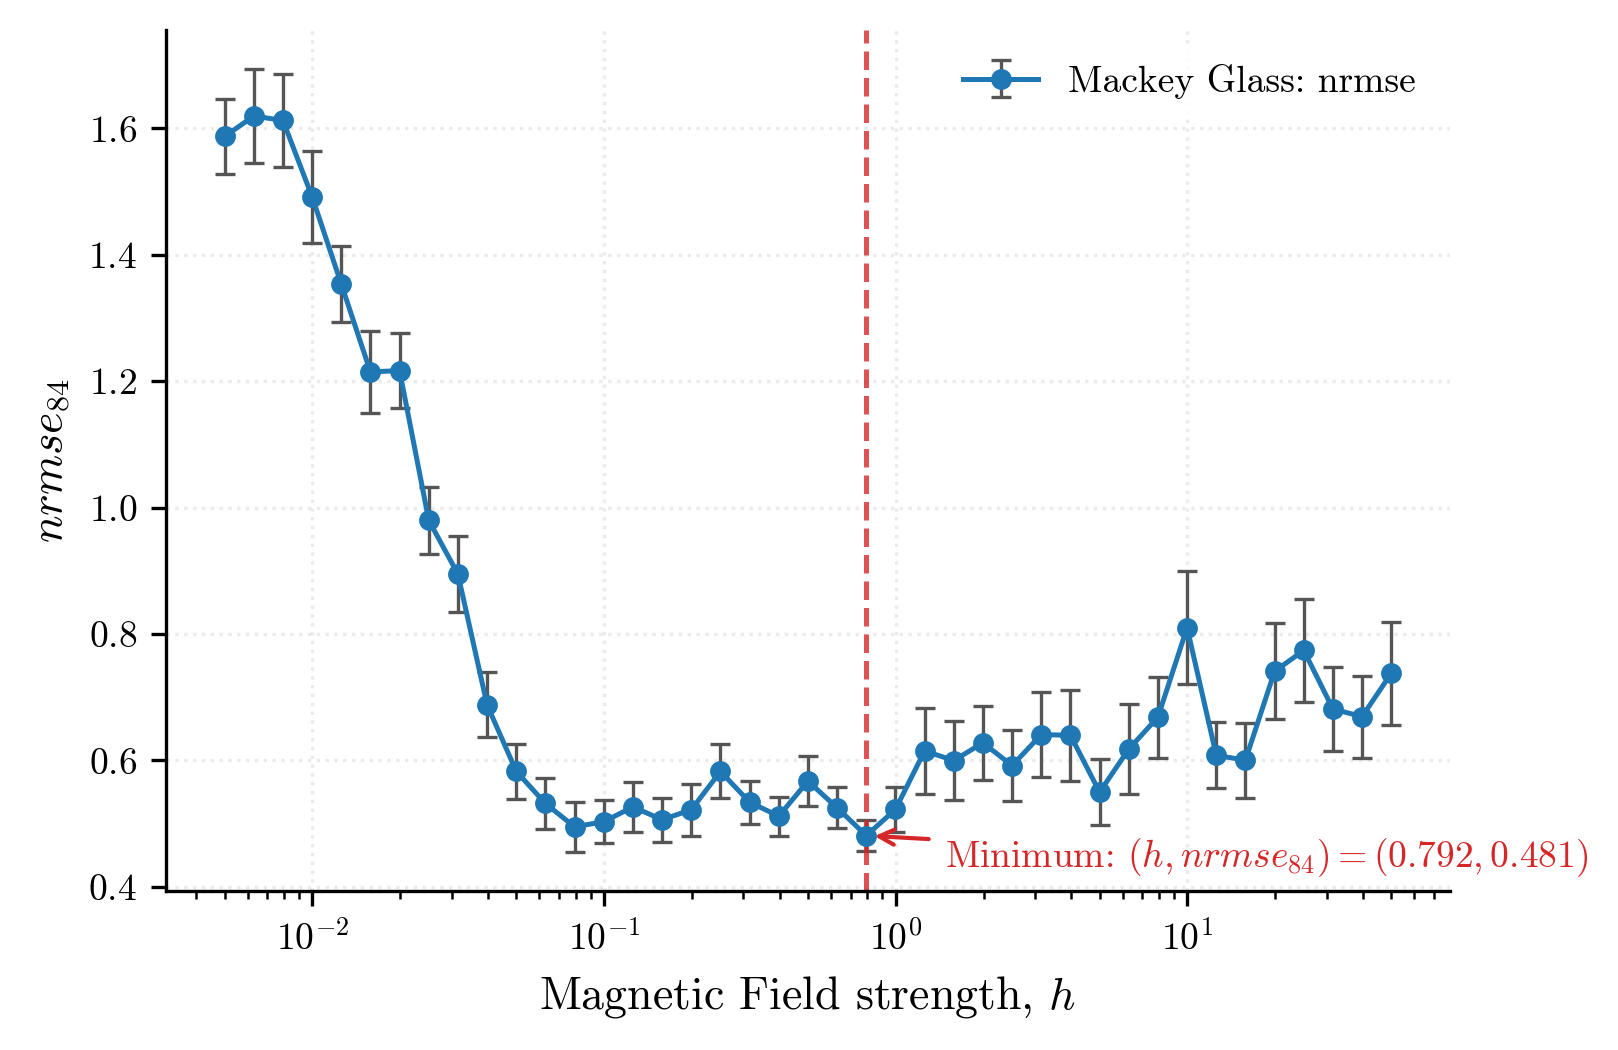

In [ ]:
def configure_academic_style():
    """Returns a clean dictionary of publication-ready matplotlib parameters."""
    return {
        "font.family": "serif",
        "font.serif": [
            "cmr10",
            "DejaVu Serif",
            "Liberation Serif",
            "Bitstream Vera Serif",
        ],
        "mathtext.fontset": "cm",  # Native Computer Modern math font
        "axes.formatter.use_mathtext": True,  # Fixes the UserWarning for cmr10 tick formatting
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": ":",
        "figure.autolayout": True,
    }

# import data
data = np.load("Data/mg/scan_mg_nrmse_84_fully_connected_tfim.npz")
mean = data['mean']
se = data["se"]
h_values = data["h_values"]

# Define colors
color = "#1f77b4"  # Muted Blue
ecolor = "#555555"
# Apply style within context block
style_config = configure_academic_style()

with plt.rc_context(style_config):
    fig, ax = plt.subplots(figsize=(5.5, 3.6), dpi=300)

    # --- Linear Memory Plot ---
    ax.errorbar(
        h_values,
        mean,
        yerr=se,
        fmt="-o",
        color=color,
        markersize=4,
        linewidth=1.2,
        capsize=2.5,
        capthick=0.8,
        elinewidth=0.8,
        ecolor=ecolor,
        label="Mackey Glass: nrmse",
    )

    x_min = 0.792
    y_min = mean[np.argmin(np.abs(h_values - x_min))] # Finds y-value at x_min=0.792

    # Vertical line
    ax.axvline(x=x_min, color="#d62728", linestyle="--", linewidth=1.2, alpha=0.8)

    # Pointing Arrow Annotation
    ax.annotate(
        r"Minimum: $(h,nrmse_{84}) = (0.792,0.481)$",
        xy=(x_min, y_min),
        xytext=(x_min * 2.5 - 0.5, y_min - 0.05),  # Text location on log scale
        arrowprops=dict(
            arrowstyle="->", 
            color="#d62728", 
            lw=1
        ),
        color="#d62728",
        fontsize=9,
        fontweight="bold"
    )

    # --- Axis & Scale Options ---
    ax.set_xscale("log")
    ax.set_yscale('linear')
    ax.set_xlabel(r"Magnetic Field strength, $h$")
    ax.set_ylabel(r"$nrmse_{84}$")

    # Visual cleanup
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend positioning
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="none",
        loc="upper right",
    )

    # Save output
    output_path = "Plots/scan_mg_nrmse_84_fully_connected_tfim.pdf"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    #fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03)
    print(f"Plot saved successfully to {output_path}")

    plt.show()

In [3]:
data = np.load("Data/mg/scan_mg_nrmse_84_fully_connected_tfim.npz")
data

NpzFile 'Data/mg/scan_mg_nrmse_84_fully_connected_tfim.npz' with keys: h_values, raw_data, mean, std, se...

In [4]:
h_values = data['h_values']
mean = data['mean']

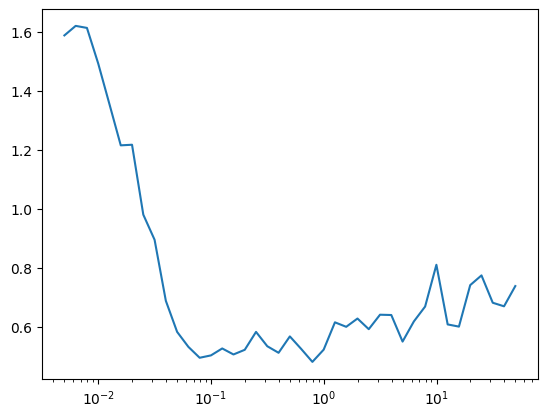

In [6]:
plt.semilogx(h_values, mean)

In [7]:
index = np.argmin(mean)
print(f'h_min = {h_values[index]}')
print(f'nrmse_min = {mean[index]}')

h_min = 0.792446596230557
nrmse_min = 0.4809840240561755
